#                            🥷🏻⚔️🔥
# ---------------------🔥 Patil warriors 🔥---------------------


# 🚚 AI Route Optimization Impact Analysis

## Business Problem Statement

Management claims that **AI Route Optimization reduces delivery time**.

As a Data Analyst, our responsibility is to validate this claim using statistical analysis and provide evidence-based recommendations to the CEO.

### Objective
Determine whether deliveries using AI Route Optimization are significantly faster than deliveries without AI Route Optimization.



# Dataset Overview

**Rows:** 500  
**Columns:** 8

### Features
- Order_ID
- Delivery_Time_Min
- Distance_KM
- Order_Value_INR
- Delivery_Partner_Rating
- Customer_Rating
- Traffic_Level
- AI_Route


In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

df = pd.read_csv('advanced_statistics_case study_data (1).csv')
df.head()

sample = df.sample(100,random_state=42)



# Case Study Questions

1. Which variables are discrete?
2. Which variables are continuous?
3. Which variables are categorical?
4. Probability that a randomly selected order used AI Route.
5. Is Traffic Level associated with AI Route?
6. Check whether Delivery Time follows normal distribution.
7. Probability that delivery time exceeds 40 minutes.
8. Calculate ±1 SD range and Z-score for 50  min .
9. Estimate average delivery time for future deliveries.
10. Test company claim that average delivery time is 30 min.
11. Test whether AI Route Optimization reduces delivery time.

## Final Business Question
Should the company continue AI Route Optimization?


# 1. Which variables are discrete?
# 2. Which variables are continuous?
# 3. Which variables are categorical?
### Q1–Q3 Variable Classification


In [34]:

continuous = ['Delivery_Time_Min','Distance_KM','Delivery_Partner_Rating']
discrete = ['Order_ID','Order_Value_INR','Customer_Rating']
categorical = ['Traffic_Level','AI_Route']

print('Continuous:', continuous)
print('Discrete:', discrete)
print('Categorical:', categorical)


Continuous: ['Delivery_Time_Min', 'Distance_KM', 'Delivery_Partner_Rating']
Discrete: ['Order_ID', 'Order_Value_INR', 'Customer_Rating']
Categorical: ['Traffic_Level', 'AI_Route']


# 4. Probability that a randomly selected order used AI Route.
###  Probability of Using AI Route

In [35]:

prob_ai = (df['AI_Route']=='Yes').mean()
print(f'Probability of AI Route: {prob_ai:.2%}')


Probability of AI Route: 54.40%


In [36]:
df["AI_Route"].value_counts(normalize=True)*100

,proportion
AI_Route,
Yes,54.4
No,45.6


# 5. Is Traffic Level associated with AI Route?
### Chi-Square Test: Traffic Level vs AI Route

###  - Chi-Square Test of Independence is used to check whether two categorical variables
### - are significantly associated with each other or independent.

In [37]:

cont_table = pd.crosstab(df['Traffic_Level'],df['AI_Route'])

chi2,p,dof,expected = st.chi2_contingency(cont_table)

print(cont_table)
print('\nP-value:',p)


AI_Route        No  Yes
Traffic_Level          
High            60   74
Low             63   76
Medium         105  122

P-value: 0.9606629994400364


# 6.Check whether Delivery Time follows normal distribution.
### Normality Test

<Axes: xlabel='Delivery_Time_Min', ylabel='Density'>

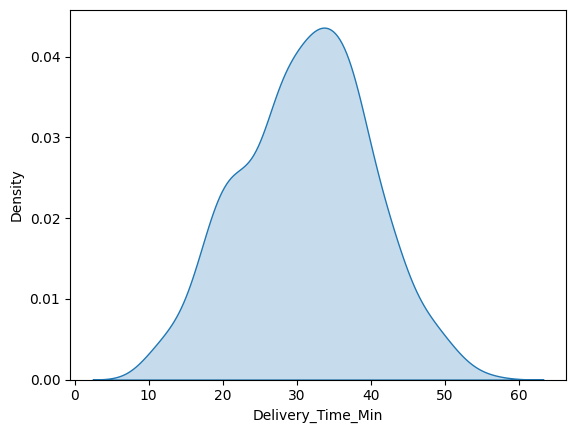

In [38]:
sns.kdeplot(df["Delivery_Time_Min"],fill=True)

### Calculate skewness and kurtosis of Delivery_Time_Min to understand the distribution shape

In [39]:
print("Skew :",df["Delivery_Time_Min"].skew(), "Kurtosis :", df["Delivery_Time_Min"].kurtosis())

Skew : -0.05728752639007957 Kurtosis : -0.38253452715029823


### It compares the actual data distribution with a theoretical normal distribution.

Text(0.5, 1.0, 'Q-Q Plot using SciPy')

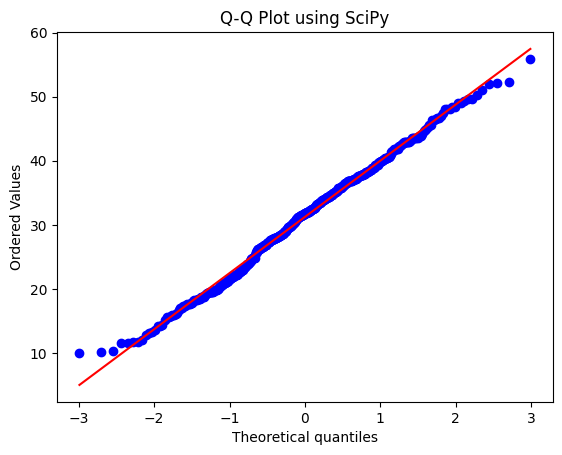

In [40]:
# Plot Q-Q plot
st.probplot(df['Delivery_Time_Min'], dist="norm", plot=plt)
plt.title("Q-Q Plot using SciPy")

### shapirio gives us result using probability

In [41]:
st.shapiro(df["Delivery_Time_Min"])

ShapiroResult(statistic=np.float64(0.9945020871293848), pvalue=np.float64(0.06969059846716046))

# 7. Probability that delivery time exceeds 40 minutes.
###  Probability Delivery Time > 40 Minutes

In [42]:

prob = (df['Delivery_Time_Min']>40).mean()
print(f'Probability: {prob:.2%}')


Probability: 15.20%


###  - Using mean and standard deviation to understand the distribution of Delivery_Time_Min.

### - CDF (Cumulative Distribution Function) is used to calculate the probability
### - that a value is less than or equal to a given point.

In [43]:
#  Using Statistics
mean=df["Delivery_Time_Min"].mean()
std = df["Delivery_Time_Min"].std()

# Using CDF methods

(1-st.norm.cdf(x=40,loc=mean,scale=std))*100

np.float64(15.805795670859668)

# 8.Calculate ±1 SD range and Z-score for 50 min .
### Standard Deviation & Z-Score

#### - This code uses the concept of Normal Distribution to analyze Delivery_Time_Min.

#### - ±1 Standard Deviation range shows how much data is close to the mean.
#### - It calculates the probability of delivery times falling within one standard deviation.
#
#### - Z-score shows how many standard deviations a value is away from the mean.
#### - A positive z-score means the value is above the mean.
#### - A negative z-score means the value is below the mean.

In [44]:
#        x - mean
#   z = ---------
#          std

x1=(1*std)+mean

x2=(-1*std)+mean
sd_range= st.norm.cdf(x=x1,loc=mean,scale=std)-st.norm.cdf(x=x2,loc=mean,scale=std)

z_score = (50-mean)/std

print('Mean:',mean)
print('Std:',std)
print('Within ±1 SD:',sd_range*100)
print('Z-score for 50 min:',z_score)


Mean: 31.238400000000002
Std: 8.739998890228899
Within ±1 SD: 68.26894921370861
Z-score for 50 min: 2.1466364281779255


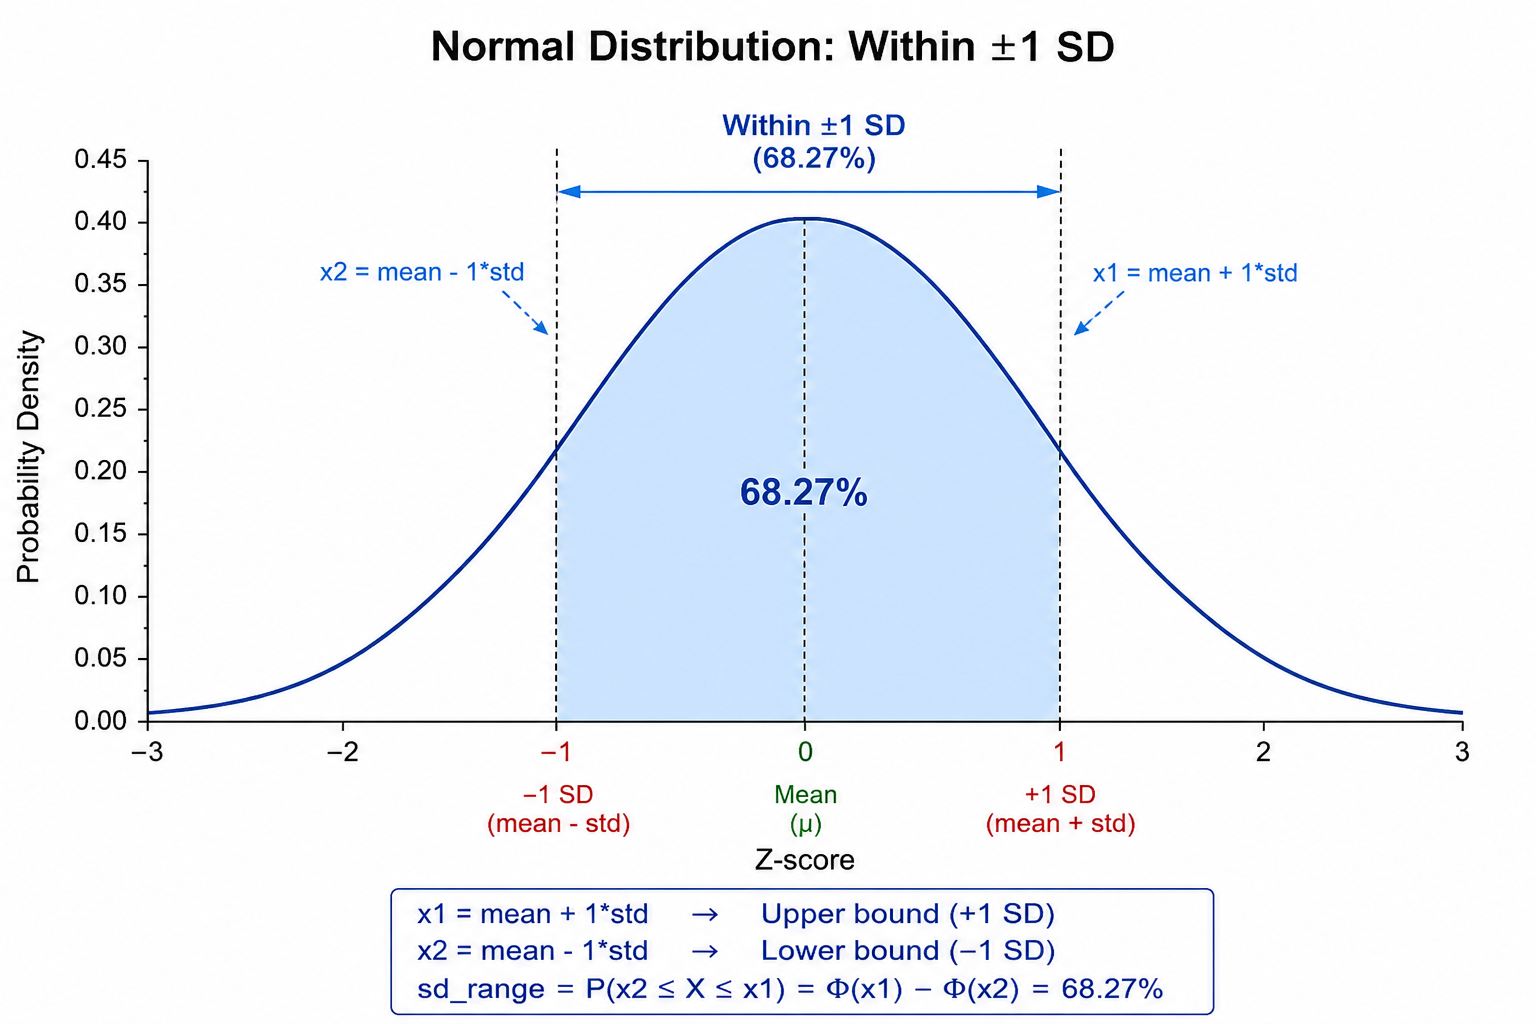

# 9.Estimate average delivery time for future deliveries.
### Confidence Interval for Future Deliveries

#### - Confidence Interval (CI) is used to estimate a range of values
#### - within which the true population mean is expected to lie.

#### - Here, a 95% confidence interval is calculated for the average Delivery_Time_Min.

In [51]:

st.t.interval(
    confidence=0.95,
    df=len(sample),
    loc=sample['Delivery_Time_Min'].mean(),
    scale=st.sem(sample['Delivery_Time_Min'])
)


(np.float64(29.419362904881137), np.float64(32.754637095118866))

### Actual Population mean

In [52]:
df['Delivery_Time_Min'].mean()

np.float64(31.238400000000002)


# 10. Test company claim that average delivery time is 30 min.
One-Sample T-Test (Claim = 30 min)

#### - One Sample T-Test is used to check whether the sample mean is significantly
#### - different from a given population mean.
#
#
#### - Here, we are testing whether the average Delivery_Time_Min is different from 30 minutes.
#
#
#### H0 : Mean delivery time = 30 minutes
#### H1 : Mean delivery time ≠ 30 minutes
#
#
#### If p-value < 0.05:
####     → Reject H0 (significant difference exists)
#### If p-value >= 0.05:
####     → Fail to reject H0 (no significant difference)

In [47]:
print(st.ttest_1samp(sample['Delivery_Time_Min'],30))
# print('T-statistic:',t_stat)
# print('P-value:',p_val)


TtestResult(statistic=np.float64(1.2931932534164678), pvalue=np.float64(0.19895373777810943), df=np.int64(99))


# 11. Test whether AI Route Optimization reduces delivery time.

#### Independent Two-Sample T-Test is used to compare the means of two independent groups.
#
#### Here, we compare delivery times between:
####   1. Orders using AI Route
####   2. Orders not using AI Route
#
#### H0 : Mean delivery time using AI Route <= Mean delivery time using Not AI Route
#### H1 : Mean delivery time using AI Route > Mean delivery time using Not AI Route

 #### Before applying the t-test, we check assumptions:

#### 1. Normality:
####    - Both groups should approximately follow a normal distribution.
####    - Can be checked using Shapiro-Wilk test or Q-Q plot.
#
#### 2. Homoscedasticity (Equal Variance):
####    - The two groups should have similar variances.

In [53]:
ai_yes = sample[sample['AI_Route']=='Yes']['Delivery_Time_Min']
ai_no = sample[sample['AI_Route']=='No']['Delivery_Time_Min']


In [55]:
# 1. Normality:
print(st.shapiro(ai_yes))
print(st.shapiro(ai_no))

ShapiroResult(statistic=np.float64(0.972006081719441), pvalue=np.float64(0.2359333768823591))
ShapiroResult(statistic=np.float64(0.9868189380144013), pvalue=np.float64(0.875661709056182))


In [57]:
# 2. Homoscedasticity (Equal Variance):
st.levene(ai_yes,ai_no)

LeveneResult(statistic=np.float64(3.202459002521516), pvalue=np.float64(0.0766164986953977))

In [58]:
t_stat,p_val = st.ttest_ind(ai_yes,ai_no,equal_var=False)

print('AI Route Mean:',ai_yes.mean())
print('Non-AI Mean:',ai_no.mean())
print('T-statistic:',t_stat)
print('P-value:',p_val)


AI Route Mean: 29.814814814814813
Non-AI Mean: 32.5804347826087
T-statistic: -1.6772482521241416
P-value: 0.09668125796605805



# CEO Recommendation Template

### If p-value > 0.05
- AI Route significantly reduces delivery time.
- Continue investment.
- Expand implementation.

### If p-value <= 0.05
- Insufficient evidence.
- Re-evaluate strategy.
- Conduct further testing.
